# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

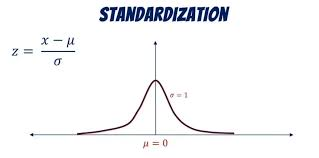


In [1]:
from google.colab import files
uploaded = files.upload()

Saving Life Expectancy Data.csv to Life Expectancy Data.csv


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

# Mount the dataset file
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
raw = np.genfromtxt('Life Expectancy Data.csv', delimiter=',', dtype=str, encoding='utf-8')
# print(raw)
headers = raw[0]
data = raw[1:]

african_countries = [
    'Algeria','Angola','Benin','Botswana','Burkina Faso','Burundi','Cabo Verde',
    'Cameroon','Central African Republic','Chad','Comoros','Congo',"Côte d'Ivoire",
    'Democratic Republic of the Congo','Djibouti','Egypt','Equatorial Guinea','Eritrea',
    'Ethiopia','Gabon','Gambia','Ghana','Guinea','Guinea-Bissau','Kenya','Lesotho',
    'Liberia','Libya','Madagascar','Malawi','Mali','Mauritania','Mauritius','Morocco',
    'Mozambique','Namibia','Niger','Nigeria','Rwanda','Sao Tome and Principe','Senegal',
    'Sierra Leone','Somalia','South Africa','South Sudan','Sudan','Togo','Tunisia',
    'Uganda','Zambia','Zimbabwe'
]

mask = np.isin(data[:, 0], african_countries)
african_data = data[mask]
print('African rows:', african_data.shape[0])
print('Matched countries:', len(np.unique(african_data[:, 0])))

# drop Country, Year, Status
country_col = african_data[:, 0]
status_col  = african_data[:, 2]
numeric_cols = [3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21]
numeric_data = african_data[:, numeric_cols].copy()

# handle missing values
numeric_data = np.where(numeric_data == '', 'nan', numeric_data).astype(float)
print('Missing values:', np.sum(np.isnan(numeric_data)))

for col in range(numeric_data.shape[1]):
    col_mean = np.nanmean(numeric_data[:, col])
    numeric_data[np.isnan(numeric_data[:, col]), col] = col_mean

print('Missing after fill:', np.sum(np.isnan(numeric_data)))
print('Shape:', numeric_data.shape)

# standardize
mean = np.mean(numeric_data, axis=0)
std = np.std(numeric_data, axis=0, ddof=1)
standardized_data = (numeric_data - mean) / std

print('\nMeans (should be ~0):', standardized_data.mean(axis=0)[:3])
print('Stds (should be ~1):', standardized_data.std(axis=0)[:3])
print(standardized_data[:5])

African rows: 816
Matched countries: 51
Missing values: 816
Missing after fill: 0
Shape: (816, 19)

Means (should be ~0): [ 2.39187755e-15 -1.43131694e-16 -2.74834621e-17]
Stds (should be ~1): [0.99938707 0.99938707 0.99938707]
[[ 2.16228392e+00 -1.59112422e+00 -2.91287139e-01  2.67300256e-15
  -5.05643511e-01  9.13032492e-01 -2.50132261e-01  2.86864872e+00
  -3.48922553e-01  9.32990504e-01 -1.32034664e-15  9.19998057e-01
  -6.82797073e-01  1.16160416e+00  1.72639086e+00 -4.77817101e-01
  -5.11220628e-01  1.84059068e+00  1.84947319e+00]
 [ 2.13694066e+00 -1.64255959e+00 -2.91287139e-01 -9.46583503e-01
  -2.32666695e-01  9.13032492e-01 -2.53872058e-01  2.78186939e+00
  -3.48922553e-01  9.32990504e-01  9.04167184e-01  9.19998057e-01
  -6.82797073e-01 -3.78836225e-01  1.68409750e+00 -4.77817101e-01
  -5.11220628e-01  1.82773125e+00  1.84947319e+00]
 [ 2.12426902e+00 -9.93188029e-01 -2.91287139e-01 -7.50963836e-01
   2.23458103e+00  9.13032492e-01 -2.52388012e-01  2.68720102e+00
  -3.48922

### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

Covariance matrix shape: (19, 19)


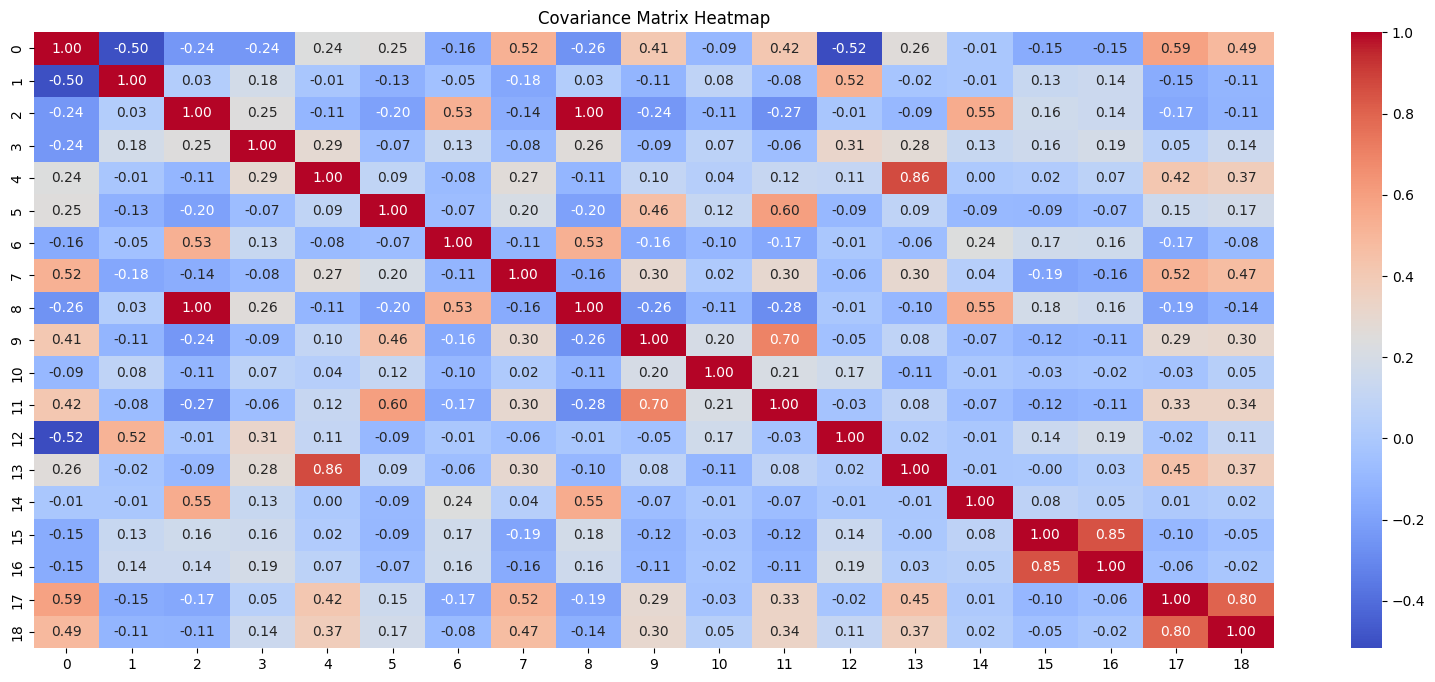

In [4]:
# The covariance matrix shows how each health indicator relates to every other one
n = standardized_data.shape[0]
# cov_matrix = (standardized_data.T @ standardized_data) / (n - 1)
# cov_matrix = np.cov(standardized_data.T)
cov_matrix = np.cov(standardized_data, rowvar=False)

print('Covariance matrix shape:', cov_matrix.shape)

# visualize the covariance matrix

import seaborn as sns

plt.figure(figsize=(20, 8))
sns.heatmap(cov_matrix, annot=True, cmap="coolwarm", fmt='.2f')
plt.title("Covariance Matrix Heatmap")
plt.show()

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons:

The covariance matrix shows us how each health indicator is related to the others. For example, it tells us if countries with higher GDP also tend to have higher life expectancy. We also need it because PCA uses it to find the most important directions in the data, which become our principal components.

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [5]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)  # Perform eigendecomposition
eigenvalues, eigenvectors

(array([2.05514601e-03, 1.10174935e-01, 1.48652601e-01, 1.69595023e-01,
        1.79688643e-01, 2.62329865e-01, 4.20248112e-01, 4.72655700e-01,
        5.06890232e-01, 5.39818351e-01, 6.74813022e-01, 7.55040477e-01,
        8.71193481e-01, 1.06588819e+00, 1.54939187e+00, 1.72071575e+00,
        2.26636764e+00, 2.75063414e+00, 4.53384683e+00]),
 array([[-5.08491927e-03,  1.99203769e-01, -1.41013456e-01,
         -2.86909665e-01,  7.09420247e-01, -1.17259575e-01,
          1.94822226e-01,  5.05032355e-02,  1.01760891e-01,
          1.00702415e-01, -5.76614880e-02, -3.31973660e-02,
         -8.23321926e-02, -8.04105470e-02, -2.20345985e-01,
          4.67775911e-02, -2.87825363e-01, -7.41728659e-02,
         -3.51146289e-01],
        [-6.93243513e-03, -2.10364949e-02,  1.03483140e-02,
         -1.78196231e-02,  1.40638659e-01,  8.16304518e-02,
          4.54347171e-01,  4.25856359e-01,  3.66160513e-02,
          2.87259966e-01,  1.44443988e-01, -3.12234356e-01,
          3.11948598e-01, -

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [6]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]  # Sort eigenvalues in descending order
print(sorted_indices)
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]  # Sort eigenvectors accordingly
sorted_eigenvectors

[18 17 16 15 14 13 12 11 10  9  8  7  6  5  4  3  2  1  0]


array([[-3.51146289e-01, -7.41728659e-02, -2.87825363e-01,
         4.67775911e-02, -2.20345985e-01, -8.04105470e-02,
        -8.23321926e-02, -3.31973660e-02, -5.76614880e-02,
         1.00702415e-01,  1.01760891e-01,  5.05032355e-02,
         1.94822226e-01, -1.17259575e-01,  7.09420247e-01,
        -2.86909665e-01, -1.41013456e-01,  1.99203769e-01,
        -5.08491927e-03],
       [ 1.42442123e-01, -1.81903809e-02,  4.01771128e-01,
        -9.53321151e-02,  2.47562874e-01, -1.81426127e-01,
         3.11948598e-01, -3.12234356e-01,  1.44443988e-01,
         2.87259966e-01,  3.66160513e-02,  4.25856359e-01,
         4.54347171e-01,  8.16304518e-02,  1.40638659e-01,
        -1.78196231e-02,  1.03483140e-02, -2.10364949e-02,
        -6.93243513e-03],
       [ 2.77606968e-01, -3.31095972e-01, -2.96582849e-01,
        -1.35845057e-01,  1.42832089e-01,  3.90728578e-03,
         2.75014969e-02, -3.14556119e-02, -3.09769890e-02,
         6.54317820e-02,  3.86846920e-02,  2.98284238e-01,
    

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [7]:
# Step 6: Project Data onto Principal Components
eigenvalues_sum = eigenvalues.sum()
num_components = 0  # Decide on the number of principal components to keep
sum = 0.0
for i in range(len(eigenvalues)):
    result = sorted_eigenvalues[i] / eigenvalues_sum
    if sum < 0.8:
        sum += result
        num_components += 1
    print(f"PC{i}: {result:.1%}")

print(sum, num_components)
new_base = sorted_eigenvectors[:, :num_components]
reduced_data = standardized_data @ new_base # Project data onto the principal components
reduced_data[:5]

PC0: 23.9%
PC1: 14.5%
PC2: 11.9%
PC3: 9.1%
PC4: 8.2%
PC5: 5.6%
PC6: 4.6%
PC7: 4.0%
PC8: 3.6%
PC9: 2.8%
PC10: 2.7%
PC11: 2.5%
PC12: 2.2%
PC13: 1.4%
PC14: 0.9%
PC15: 0.9%
PC16: 0.8%
PC17: 0.6%
PC18: 0.0%
0.8164778089281137 8


array([[-4.07800683, -1.72374915, -2.22433968, -0.31925023,  0.08050408,
        -1.29075807, -0.37427425, -0.38928614],
       [-3.91633967, -0.88748145, -2.46277729, -0.98562953,  0.06164397,
        -1.91985476, -1.12810192, -0.32181176],
       [-4.69131796, -2.53073017, -1.31207716,  0.21038263,  0.38243911,
        -0.18797906, -1.10882903, -1.16467985],
       [-4.64357425, -2.57240877, -1.33532616,  0.39060924,  0.28179213,
        -0.10713109, -0.71383161, -1.2018085 ],
       [-4.47733976, -2.40090824, -1.44340054,  0.44839402,  0.16299956,
        -0.13606102, -0.33231368, -1.24044001]])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [8]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

Reduced Data Shape: (816, 8)


array([[-4.07800683, -1.72374915, -2.22433968, -0.31925023,  0.08050408,
        -1.29075807, -0.37427425, -0.38928614],
       [-3.91633967, -0.88748145, -2.46277729, -0.98562953,  0.06164397,
        -1.91985476, -1.12810192, -0.32181176],
       [-4.69131796, -2.53073017, -1.31207716,  0.21038263,  0.38243911,
        -0.18797906, -1.10882903, -1.16467985],
       [-4.64357425, -2.57240877, -1.33532616,  0.39060924,  0.28179213,
        -0.10713109, -0.71383161, -1.2018085 ],
       [-4.47733976, -2.40090824, -1.44340054,  0.44839402,  0.16299956,
        -0.13606102, -0.33231368, -1.24044001]])

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

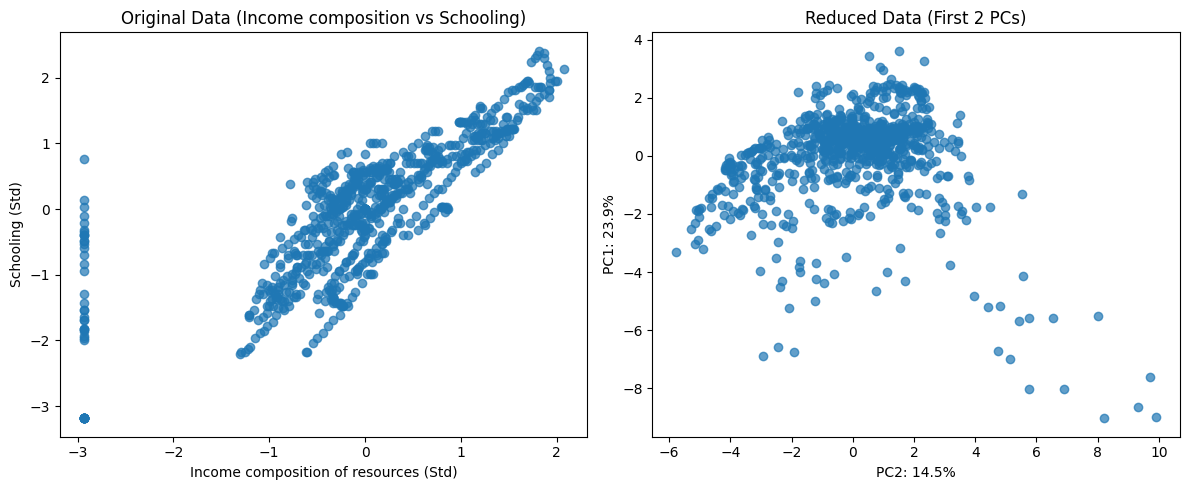

In [9]:
# Step 8: Visualize Before and After PCA

plt.figure(figsize=(12, 5))

# Plot original data (two highly correlated features)
plt.subplot(1, 2, 1)
plt.scatter(standardized_data[:, 17], standardized_data[:, 18], alpha=0.7)
plt.title("Original Data (Income composition vs Schooling)")
plt.xlabel("Income composition of resources (Std)")
plt.ylabel("Schooling (Std)")

# Plot reduced data after PCA
plt.subplot(1, 2, 2)
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], alpha=0.7)
plt.title("Reduced Data (First 2 PCs)")
plt.ylabel(f"PC1: {(sorted_eigenvalues[0]*100/eigenvalues.sum()):.1f}%")
plt.xlabel(f"PC2: {(sorted_eigenvalues[1]*100/eigenvalues.sum()):.1f}%")

plt.tight_layout()
plt.show()

Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA

The left plot shows a clear diagonal pattern, meaning income composition and schooling are strongly correlated, when one goes up, the other goes up as well. The right plot looks more spread out because it now summarizes all 19 features into just 2 components, showing the overall structure of the whole dataset.

2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making

We kept components that together explain at least 80% of the data. By doing this we are keeping most of the important information while making the data smaller and also simpler. The tradeoff is that the remaining 20% of information is thrown away, so naturally some small details about certain countries are lost

3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?


When we compressed 19 columns into a few, we lost some details. For example, two countries might have very different GDP or HIV rates but look the same in the compressed data so we keep the big picture but lose the small details.


GitHub Repository: https://github.com/Esther-Mahoro04/african-health-pca